# Word Embeddings in Keras & TensorFlow using Word2Vec


##  What are Word Embeddings?

A word embedding represents a word as a **dense numerical vector**.

Unlike one-hot encoding, embeddings can capture relationships between words because words appearing in similar contexts can learn similar vector representations.

Example:

`machine → [0.21, -0.14, 0.72, ...]`

**Word2Vec** learns these representations from word-context relationships.

Two main architectures are:

- **CBOW:** context words → target word
- **Skip-gram:** target word → context words

We will use here **Skip-gram**.

In [1]:
import re
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.22.0-rc0


## Create a Small Training Corpus

A real Word2Vec model normally requires a much larger corpus. This small corpus is used so that the complete process is easy to understand.

In [2]:
sentences = [
    "machine learning is a part of artificial intelligence",
    "deep learning is a part of machine learning",
    "artificial intelligence uses machine learning",
    "neural networks are used in deep learning",
    "python is popular for machine learning",
    "python is also popular for data science",
    "data science uses statistics and machine learning",
    "natural language processing works with text",
    "word embeddings represent words as vectors",
    "word2vec learns useful word embeddings",
    "deep learning models learn representations",
    "machine learning models learn patterns from data"
]

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

tokenized = [tokenize(s) for s in sentences]

for s in tokenized[:3]:
    print(s)

['machine', 'learning', 'is', 'a', 'part', 'of', 'artificial', 'intelligence']
['deep', 'learning', 'is', 'a', 'part', 'of', 'machine', 'learning']
['artificial', 'intelligence', 'uses', 'machine', 'learning']


## Build the Vocabulary

Each unique word is assigned an integer ID. Neural networks work with these IDs rather than raw words.

In [3]:
vocabulary = sorted(set(w for s in tokenized for w in s))
word_to_id = {w: i for i, w in enumerate(vocabulary)}
id_to_word = {i: w for w, i in word_to_id.items()}

vocab_size = len(vocabulary)

print("Vocabulary size:", vocab_size)
print(vocabulary)

Vocabulary size: 43
['a', 'also', 'and', 'are', 'artificial', 'as', 'data', 'deep', 'embeddings', 'for', 'from', 'in', 'intelligence', 'is', 'language', 'learn', 'learning', 'learns', 'machine', 'models', 'natural', 'networks', 'neural', 'of', 'part', 'patterns', 'popular', 'processing', 'python', 'represent', 'representations', 'science', 'statistics', 'text', 'used', 'useful', 'uses', 'vectors', 'with', 'word', 'word2vec', 'words', 'works']


## Convert Sentences to Integer IDs

In [4]:
encoded = [[word_to_id[w] for w in s] for s in tokenized]

for words, ids in zip(tokenized[:3], encoded[:3]):
    print("Words:", words)
    print("IDs:  ", ids)
    print()

Words: ['machine', 'learning', 'is', 'a', 'part', 'of', 'artificial', 'intelligence']
IDs:   [18, 16, 13, 0, 24, 23, 4, 12]

Words: ['deep', 'learning', 'is', 'a', 'part', 'of', 'machine', 'learning']
IDs:   [7, 16, 13, 0, 24, 23, 18, 16]

Words: ['artificial', 'intelligence', 'uses', 'machine', 'learning']
IDs:   [4, 12, 36, 18, 16]



## Generate Skip-gram Training Pairs

With a window size of 2, each target word is paired with nearby context words.

For example:

`machine learning is useful`

can generate pairs such as:

`learning → machine`

`learning → is`

The model learns to predict the context word from the target word.

In [5]:
window_size = 2
targets = []
contexts = []

for sentence in encoded:
    for i, target in enumerate(sentence):
        start = max(0, i - window_size)
        end = min(len(sentence), i + window_size + 1)

        for j in range(start, end):
            if i != j:
                targets.append(target)
                contexts.append(sentence[j])

targets = np.array(targets, dtype=np.int32)
contexts = np.array(contexts, dtype=np.int32)

print("Training pairs:", len(targets))
for t, c in zip(targets[:10], contexts[:10]):
    print(id_to_word[t], "->", id_to_word[c])

Training pairs: 236
machine -> learning
machine -> is
learning -> machine
learning -> is
learning -> a
is -> machine
is -> learning
is -> a
is -> part
a -> learning


## Build Word2Vec with Keras

The model contains:

**Target word ID → Embedding layer → Dense softmax → Context-word prediction**

The Keras `Embedding` layer stores one trainable vector for every vocabulary word.

If `embedding_dim = 50`, every word is represented by a vector containing 50 numbers.

In [7]:
embedding_dim = 50

word2vec = keras.Sequential([
    layers.Input(shape=(1,), dtype=tf.int32),
    layers.Embedding(vocab_size, embedding_dim, name="word_embedding"),
    layers.Flatten(),
    layers.Dense(vocab_size, activation="softmax")
])

word2vec.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

word2vec.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ word_embedding (Embedding)           │ (None, 1, 50)               │           2,150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │           2,193 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,343 (16.96 KB)

 Trainable params: 4,343 (16.96 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Word2Vec Model

The target is the context-word ID.

Because this is a tiny teaching corpus, the resulting embeddings should not be considered high-quality linguistic embeddings. Larger corpora generally produce much better representations.

In [8]:
history = word2vec.fit(
    targets,
    contexts,
    epochs=100,
    batch_size=16,
    verbose=0
)

print("Final loss:", history.history["loss"][-1])
print("Final accuracy:", history.history["accuracy"][-1])

Final loss: 1.6937605142593384
Final accuracy: 0.2881355881690979


## Plot Training Loss

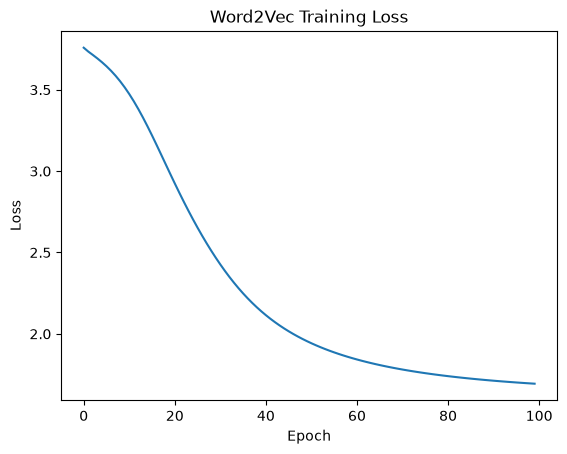

In [9]:
plt.plot(history.history["loss"])
plt.title("Word2Vec Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Extract the Learned Embeddings

The embedding matrix has shape:

`(vocabulary size, embedding dimension)`

Each row corresponds to one word.

In [15]:
embedding_matrix = word2vec.get_layer("word_embedding").get_weights()[0]

print("Embedding matrix shape:", embedding_matrix.shape)

def get_embedding(word):
    word = word.lower()
    if word not in word_to_id:
        raise ValueError(f"{word!r} is not in the vocabulary")
    return embedding_matrix[word_to_id[word]]

print("First 10 values for 'learning':")
print(get_embedding("learning")[:10])

Embedding matrix shape: (43, 50)
First 10 values for 'learning':
[ 0.28971738  0.42933533 -0.09426456  0.14920805  0.23719983  0.10504414
 -0.0545097  -0.05465337  0.04983715  0.06699053]


## Word Similarity with Cosine Similarity

Cosine similarity compares the direction of two vectors.

- Close to **1** → similar direction
- Around **0** → little directional similarity
- Close to **-1** → opposite direction

With this small corpus, similarity results are only demonstrations.

In [13]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def most_similar(word, top_n=5):
    query = get_embedding(word)
    scores = []

    for candidate in vocabulary:
        if candidate != word:
            score = cosine_similarity(query, get_embedding(candidate))
            scores.append((candidate, score))

    return sorted(scores, key=lambda x: x[1], reverse=True)[:top_n]

for word in ["learning", "python", "data"]:
    print("\nSimilar to:", word)
    print(most_similar(word))


Similar to: learning
[('part', np.float32(0.5766833)), ('representations', np.float32(0.531421)), ('intelligence', np.float32(0.43670934)), ('models', np.float32(0.3723833)), ('statistics', np.float32(0.36626798))]

Similar to: python
[('for', np.float32(0.6958953)), ('also', np.float32(0.67140675)), ('popular', np.float32(0.59573567)), ('a', np.float32(0.39201605)), ('is', np.float32(0.37971786))]

Similar to: data
[('statistics', np.float32(0.4123319)), ('also', np.float32(0.37413755)), ('for', np.float32(0.369706)), ('learn', np.float32(0.337997)), ('science', np.float32(0.33521974))]


##  Use an Embedding Layer in a Keras NLP Model

The learned Word2Vec embeddings can be used as features for another NLP model.

A typical architecture is:

**Text → Tokenization → Integer IDs → Embedding → LSTM/GRU/CNN → Prediction**

The embedding layer can be:

- trained from scratch,
- initialized with pretrained Word2Vec vectors,
- frozen, or
- fine-tuned during downstream training.

In [14]:
sequence_length = 6

downstream_model = keras.Sequential([
    layers.Input(shape=(sequence_length,), dtype=tf.int32),
    layers.Embedding(vocab_size, embedding_dim),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

downstream_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 6, 50)               │           2,150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 50)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,983 (11.65 KB)

 Trainable params: 2,983 (11.65 KB)

 Non-trainable params: 0 (0.00 B)

## CBOW vs Skip-gram

| Feature | CBOW | Skip-gram |
|---|---|---|
| Input | Context words | Target word |
| Prediction | Target word | Context words |
| Main idea | Context → Target | Target → Context |
| Training | Generally faster | Generally slower |
| Useful for | Common words | Often useful for rare words |

Example sentence:

`deep learning is powerful`

CBOW:

`deep + is → learning`

Skip-gram:

`learning → deep`

`learning → is`

## Word2Vec vs Keras Embedding

**Word2Vec** is a method for learning word representations from context.

**Keras Embedding** is a neural-network layer that maps integer word IDs to trainable dense vectors.

In this notebook, the Keras Embedding layer is trained using a Skip-gram objective, creating a simple Word2Vec-style implementation.

## Limitations of Word2Vec

1. It normally gives one static vector per word.
2. It does not naturally distinguish different meanings of the same word by context.
3. It works better with a large, representative corpus.
4. Out-of-vocabulary words are a problem.
5. Training quality depends heavily on corpus size and preprocessing.

Modern contextual models such as BERT and other transformer models overcome many of these limitations.